# Step 3 — Load Profile Visualization

This notebook turns the 8,760-hour annual demand profile built in Step 2 into the three views planned for the app: a **weekly** hourly profile, **monthly** totals, and a **yearly** overview — each with a switchable display unit (kWh / MWh / TWh).

These are read-only views over `data/hourly_load_profile_2026.csv` — nothing here changes the underlying demand numbers. Each chart is built as a function that takes the unit as a parameter, since in the Streamlit app this becomes a dropdown the user can change live; the notebook demonstrates each function with more than one unit to prove the switch actually works.

## 3.1 Setup

Same pattern as Steps 1 and 2: imports, locate `data/`, load the hourly profile saved at the end of Step 2. Chart styling (fonts, colors, gridlines) is reused exactly from Step 1's `CATEGORY_COLORS` mapping, so a category is drawn in the same color in every chart across the whole project.

In [1]:
import pandas as pd  # pandas: tabular data (DataFrames)
import numpy as np  # numpy: numerical operations
import matplotlib.pyplot as plt  # matplotlib.pyplot: the plotting library used for every chart below
# inline: force charts to render directly in the notebook output instead of a separate GUI window — avoids a chart
# cell hanging forever locally if matplotlib happens to default to an interactive backend on your machine
%matplotlib inline
import matplotlib.dates as mdates  # mdates: nicely formatted date ticks on time-series x-axes
from pathlib import Path  # Path: OS-independent file paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # find the project's root folder regardless of where the notebook is run from
DATA_DIR = PROJECT_ROOT / "data"  # the shared data/ folder used by every notebook

hourly_profile = pd.read_csv(DATA_DIR / "hourly_load_profile_2026.csv", parse_dates=["date"])  # read_csv(): load Step 2's finished annual profile, parsing the date column as real dates
print(f"Loaded {len(hourly_profile):,} hours, {hourly_profile['date'].min().date()} to {hourly_profile['date'].max().date()}")
hourly_profile.head(3)

Loaded 8,760 hours, 2026-01-01 to 2026-12-31


,hour_of_year,day,hour_of_day,date,day_type,A_wh,B_wh,C_wh,Misc_wh,total_wh
0,1,1,0,2026-01-01,January,40200.0,185000.0,0.0,36100.0,261300.0
1,2,1,1,2026-01-01,January,40200.0,185000.0,0.0,36100.0,261300.0
2,3,1,2,2026-01-01,January,40200.0,185000.0,0.0,57100.0,282300.0


In [2]:
# Fixed category -> color mapping, same as Step 1 — reused across every chart in this project so a category
# always means the same color everywhere.
CATEGORY_COLORS = {
    "A": "#2a78d6",     # blue
    "B": "#eb6834",     # orange
    "C": "#1baf7a",     # aqua
    "Misc": "#eda100",  # yellow
}
CATEGORIES = list(CATEGORY_COLORS.keys())  # the stacking order used by every stacked chart below
GRIDLINE = "#e1e0d9"  # hairline gridline color
AXIS_INK = "#c3c2b7"  # axis border line color
TEXT_PRIMARY = "#0b0b0b"  # main text color (titles, data labels)
TEXT_MUTED = "#898781"  # muted color for axis tick labels

plt.rcParams["font.family"] = "sans-serif"  # rcParams: matplotlib's global default font family for every chart in this notebook
plt.rcParams["axes.edgecolor"] = AXIS_INK
plt.rcParams["text.color"] = TEXT_PRIMARY
plt.rcParams["axes.labelcolor"] = TEXT_PRIMARY
plt.rcParams["xtick.color"] = TEXT_MUTED
plt.rcParams["ytick.color"] = TEXT_MUTED

## 3.2 Switchable display units

Every value in `hourly_load_profile_2026.csv` is stored in **Wh** (watt-hours) — the same base unit Step 2 computed in. The app needs to display these as kWh, MWh, or TWh depending on what's being shown (an hour's demand is naturally kWh-scale; an annual total is naturally MWh-to-GWh-scale for a system this size). Rather than converting the stored data, every chart function below takes a `unit` argument and converts only for display — the underlying numbers never change.

In [3]:
UNIT_FACTORS = {"kWh": 1e-3, "MWh": 1e-6, "TWh": 1e-12}  # multiply a Wh value by this to get the chosen display unit


def convert_wh(values, unit: str):
    """Convert a Wh value (or array/Series of them) to the requested display unit. Raises if the unit isn't recognized."""
    if unit not in UNIT_FACTORS:
        raise ValueError(f"Unknown unit '{unit}'. Choose one of: {list(UNIT_FACTORS.keys())}")
    return values * UNIT_FACTORS[unit]


# Quick sanity check: the annual total in each unit should represent the same energy.
annual_total_wh = hourly_profile["total_wh"].sum()  # sum(): total Wh across all 8,760 hours
for unit in UNIT_FACTORS:  # for loop: show the same total converted to every supported unit
    print(f"Annual total: {convert_wh(annual_total_wh, unit):,.6f} {unit}")

Annual total: 3,440,337.926000 kWh
Annual total: 3,440.337926 MWh
Annual total: 0.003440 TWh


## 3.3 Weekly profile

A stacked-area chart of one representative week's hourly demand (168 hours), broken down by category (A/B/C/Misc) so the reader can see both the daily on/off pattern and which category drives it. This is a **trend-over-time, categorical-series** chart, so it uses the fixed `CATEGORY_COLORS` — same rule as `references/choosing-a-form.md` in the data-viz method: identity of the series is the point, so color is categorical, not sequential.

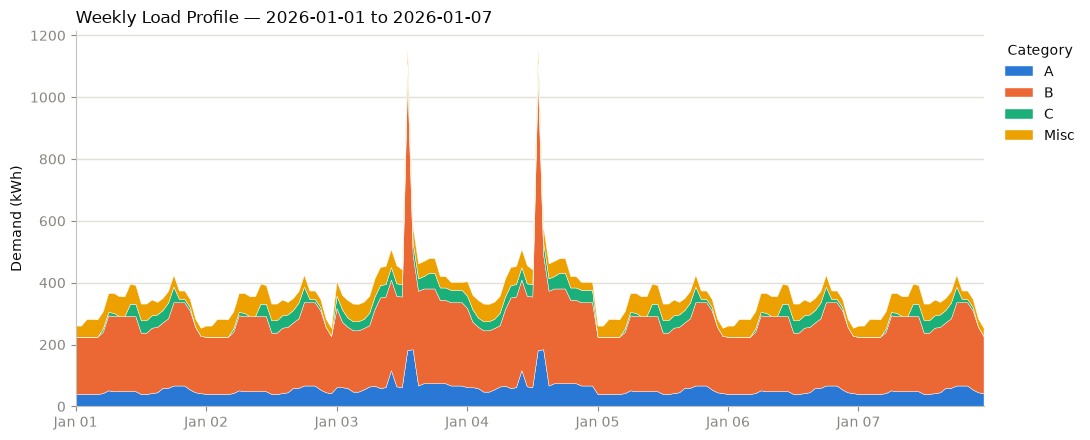

In [4]:
def plot_weekly_profile(hourly_df: pd.DataFrame, start_day: int = 1, unit: str = "kWh"):
    """Plot a stacked-area chart of one 7-day (168-hour) window's demand by category, starting at the given day-of-year (1-359)."""
    week = hourly_df[(hourly_df["day"] >= start_day) & (hourly_df["day"] < start_day + 7)].copy()  # slice: exactly 7 days = 168 hours
    if len(week) != 168:
        raise ValueError(f"start_day={start_day} does not give a full 7-day window inside the year (got {len(week)} hours)")

    week["timestamp"] = pd.to_datetime(week["date"]) + pd.to_timedelta(week["hour_of_day"], unit="h")  # build a real per-hour timestamp for the x-axis
    series = [convert_wh(week[f"{cat}_wh"], unit) for cat in CATEGORIES]  # list comprehension: one converted Series per category, in stacking order
    colors = [CATEGORY_COLORS[cat] for cat in CATEGORIES]

    fig, ax = plt.subplots(figsize=(11, 4.5))  # subplots(): create a new figure and axes to draw the chart on
    ax.stackplot(week["timestamp"], series, labels=CATEGORIES, colors=colors, edgecolor="white", linewidth=0.3)  # stackplot(): draw the stacked-area chart

    ax.xaxis.set_major_locator(mdates.DayLocator())  # DayLocator(): one tick per day
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))  # DateFormatter(): show ticks as e.g. "Jan 05"
    ax.set_ylabel(f"Demand ({unit})")
    week_start, week_end = week["date"].min().date(), week["date"].max().date()
    ax.set_title(f"Weekly Load Profile — {week_start} to {week_end}", loc="left", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)  # hide the top and right border lines
    ax.spines[["left", "bottom"]].set_color(AXIS_INK)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)  # faint horizontal gridlines behind the stacked areas
    ax.set_axisbelow(True)
    ax.set_xlim(week["timestamp"].min(), week["timestamp"].max())
    ax.legend(title="Category", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)  # legend outside the plot area, since >=2 series
    plt.tight_layout()
    plt.show()


plot_weekly_profile(hourly_profile, start_day=1, unit="kWh")  # call: first week of the year, in kWh

## 3.4 Monthly totals

A stacked-bar chart of total demand per calendar month, broken down by category — a **part-to-whole across an ordered category** (the 12 months), so a stacked bar is the right form, same categorical colors as every other chart.

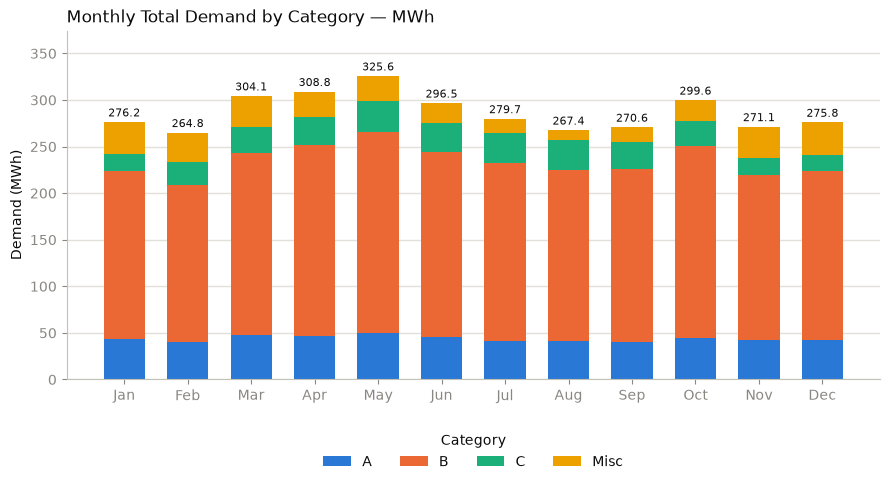

In [5]:
def plot_monthly_totals(hourly_df: pd.DataFrame, unit: str = "MWh"):
    """Plot a stacked-bar chart of total demand per calendar month, broken down by category."""
    monthly = hourly_df.copy()
    monthly["month"] = pd.to_datetime(monthly["date"]).dt.month  # dt.month: 1-12, used to group hours into calendar months
    monthly_totals = monthly.groupby("month")[[f"{cat}_wh" for cat in CATEGORIES]].sum()  # groupby().sum(): total Wh per category, per month
    month_labels = [pd.Timestamp(2026, m, 1).strftime("%b") for m in monthly_totals.index]  # Timestamp(): turn 1-12 into "Jan".."Dec" labels

    fig, ax = plt.subplots(figsize=(9, 5))  # subplots(): create a new figure and axes to draw the chart on
    bottom = np.zeros(len(monthly_totals))  # running bottom-of-stack for each bar, starts at 0
    for cat in CATEGORIES:  # for loop: stack one category's bar segment on top of the previous ones
        values = convert_wh(monthly_totals[f"{cat}_wh"], unit).values
        ax.bar(month_labels, values, bottom=bottom, color=CATEGORY_COLORS[cat], label=cat, width=0.65)  # bar(): one stacked segment per category
        bottom += values

    ax.set_ylabel(f"Demand ({unit})")
    ax.set_title(f"Monthly Total Demand by Category — {unit}", loc="left", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(AXIS_INK)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, bottom.max() * 1.15)  # headroom above the tallest stacked bar

    # Direct label: total on top of each bar (selective — one number per bar, not per segment)
    for i, total in enumerate(bottom):
        ax.text(i, total + bottom.max() * 0.01, f"{total:,.1f}", ha="center", va="bottom", fontsize=8, color=TEXT_PRIMARY)

    ax.legend(title="Category", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)  # legend below the chart
    plt.tight_layout()
    plt.show()


plot_monthly_totals(hourly_profile, unit="MWh")  # call: monthly totals in MWh

## 3.5 Yearly overview

The full year's shape, one point per day (the sum of that day's 24 hours), as a single line. This is **trend over time with one series** — total demand only, no category breakdown — so it takes the sequential blue rather than the categorical palette (`references/choosing-a-form.md`: "Trend over time -> line ... Color job: sequential or 1 categorical"), and the area under the line is filled at low opacity to make the seasonal shape easier to read at a glance.

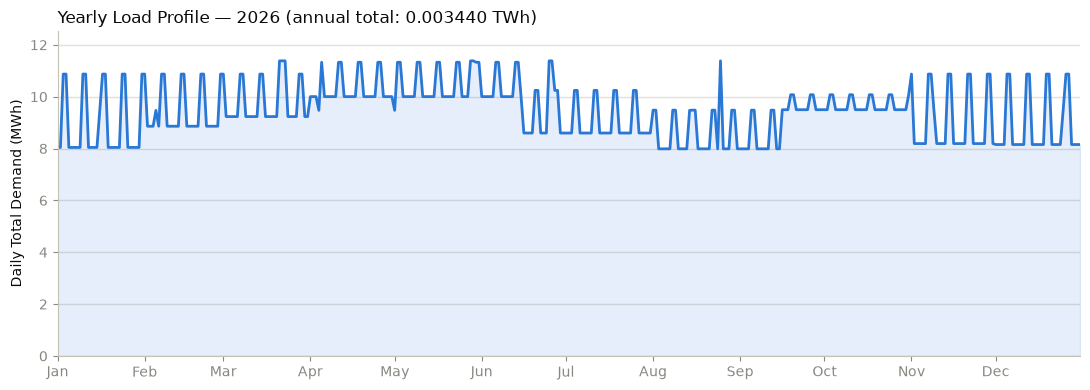

In [6]:
def plot_yearly_overview(hourly_df: pd.DataFrame, unit: str = "MWh"):
    """Plot one point per day (that day's total demand) across the full year, as a single line with a light fill."""
    daily = hourly_df.groupby("date")["total_wh"].sum().reset_index()  # groupby().sum(): collapse 24 hourly rows into 1 daily total
    daily["date"] = pd.to_datetime(daily["date"])
    daily["value"] = convert_wh(daily["total_wh"], unit)

    fig, ax = plt.subplots(figsize=(11, 4))  # subplots(): create a new figure and axes to draw the chart on
    ax.plot(daily["date"], daily["value"], color=CATEGORY_COLORS["A"], linewidth=2)  # plot(): the daily-total line, in the project's primary blue
    ax.fill_between(daily["date"], daily["value"], color=CATEGORY_COLORS["A"], alpha=0.12)  # fill_between(): light fill under the line, for readability

    ax.xaxis.set_major_locator(mdates.MonthLocator())  # MonthLocator(): one tick per month
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))  # DateFormatter(): show ticks as "Jan", "Feb", ...
    ax.set_ylabel(f"Daily Total Demand ({unit})")
    ax.set_title(f"Yearly Load Profile — 2026 (annual total: {convert_wh(daily['total_wh'].sum(), 'TWh'):.6f} TWh)", loc="left", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(AXIS_INK)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(daily["date"].min(), daily["date"].max())
    ax.set_ylim(0, daily["value"].max() * 1.1)
    plt.tight_layout()
    plt.show()


plot_yearly_overview(hourly_profile, unit="MWh")  # call: full-year daily-total overview, in MWh

## 3.6 Confirming the unit switch works

Each function above takes `unit` as a plain argument — in the Streamlit app this will be driven by a dropdown, with no other code changes needed. To prove the switch actually changes what's plotted (not just the axis label), the monthly chart below is re-drawn in all three supported units; the bar heights and the printed totals scale correctly between them, and a different week is shown to confirm `start_day` also works for an arbitrary week (this one falls in the Peak-Monsoon period, so the pattern looks different from the Jan 1 week above).

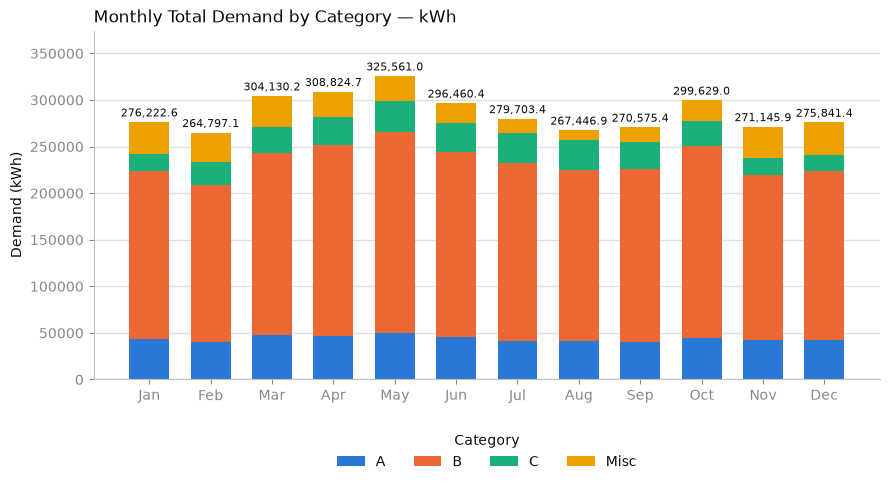

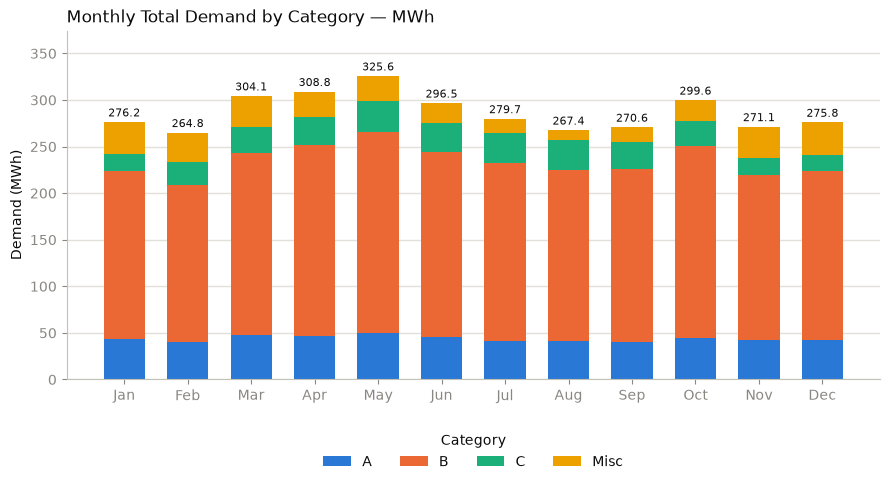

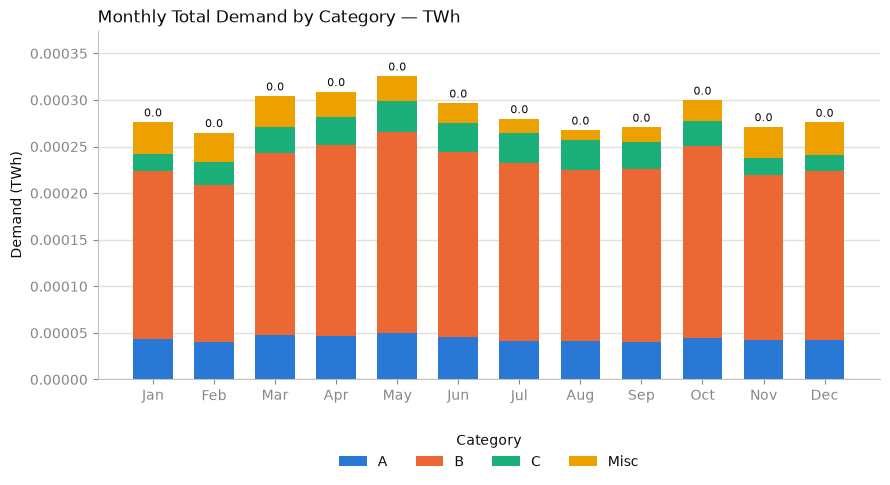

In [7]:
for unit in UNIT_FACTORS:  # for loop: redraw the same monthly chart in every supported unit
    plot_monthly_totals(hourly_profile, unit=unit)

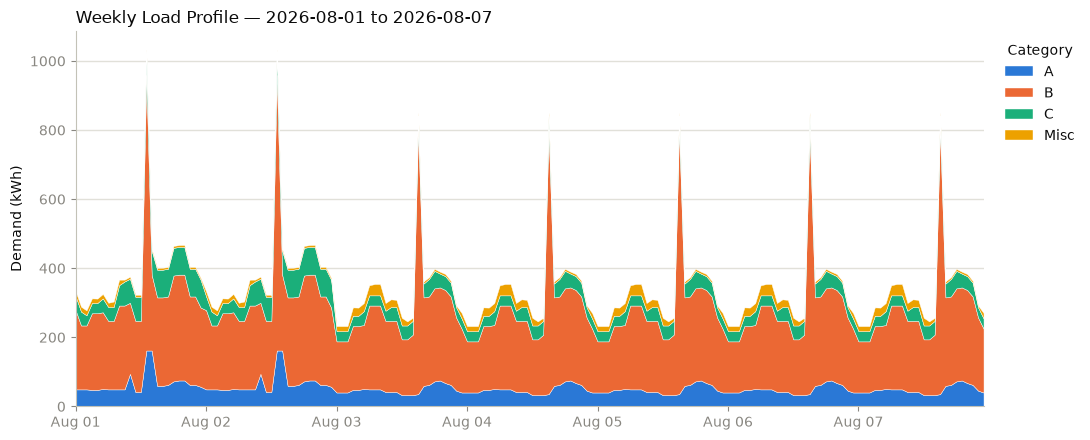

In [8]:
plot_weekly_profile(hourly_profile, start_day=213, unit="kWh")  # call: day 213 = August 1, a Peak-Monsoon week, in kWh — confirms start_day is not hardcoded to week 1

## 3.7 Summary

- Three chart functions built, each parameterized by display unit (`kWh`/`MWh`/`TWh`) and, for the weekly view, by which week to show:
  - `plot_weekly_profile(hourly_df, start_day, unit)` — stacked-area, 168-hour window, by category.
  - `plot_monthly_totals(hourly_df, unit)` — stacked-bar, 12 months, by category, with direct-labeled totals.
  - `plot_yearly_overview(hourly_df, unit)` — single-line daily-total trend across all 365 days, with the annual total in the title.
- `convert_wh()` centralizes the kWh/MWh/TWh conversion so every chart (and the eventual Streamlit unit dropdown) shares one implementation.
- Confirmed the unit switch changes the actual plotted values (not just a label) by redrawing the monthly chart in all three units, and confirmed the weekly view works for an arbitrary week, not just week 1.
- These charts use matplotlib (static), consistent with Steps 1-2. In the Streamlit app these will likely become interactive Plotly versions (already in `requirements.txt`) so the user can hover for exact values — the same category color mapping and unit conversion carry over unchanged.

**Step 3 (Load Profile Visualization) is now done.**